Importando as bibliotecas e módulos necessários: 

In [1]:
import os
import pandas as pd
import numpy as np
import sys
import gc
import scipy.stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

Importando as bases necessárias: 

In [2]:
df_2019 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2019.parquet", engine="pyarrow")
df_2021 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2021.parquet", engine="pyarrow")
df_2023 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2023.parquet", engine="pyarrow")

### Modelagem Preditiva 
Esse código implementa modelos de Regressão Logística para prever se um aluno será Insuficiente ou Proficiente.

#### Regressão Logística com Balanceamento de Pesos
O balanceamento de pesos é uma alternativa para lidar com o desbalanceamento sem fazer Undersampling nem SMOTE, evitando a criação ou a remoção de
observações. A ideia é a classe minoritária receber um peso maior e a classe majoritária receber um peso menor. Isso é especialmente interessante para essa base, que tem quase 2 milhões de registros.

#### 2019

Distribuição das classes:
PROFICIENCIA_DESCRICAO
0    1239902
1     289642
Name: count, dtype: int64

Peso classe 0: 0.6168
Peso classe 1: 2.6404

Acurácia: 0.6286

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.90      0.61      0.73    309976
 Proficiente       0.30      0.71      0.42     72411

    accuracy                           0.63    382387
   macro avg       0.60      0.66      0.57    382387
weighted avg       0.79      0.63      0.67    382387



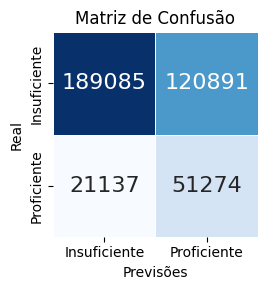

                                       Feature  Coefficient  Odds Ratio  \
0                                        const     0.643738    1.903583   
16                    QTD_COMPUTADOR_3 ou mais     0.413357    1.511885   
25              IDADE_INTROD_ESC_Não respondeu     0.336500    1.400039   
15                       QTD_COMPUTADOR_1 ou 2     0.315376    1.370775   
11                 ESCOL_MAE_Superior completo     0.291027    1.337801   
38                      POS_EF_Somente estudar     0.272464    1.313196   
20                     QTD_CARRO_Não respondeu     0.221939    1.248496   
18                            QTD_CARRO_1 ou 2     0.208868    1.232282   
8                     ESCOL_MAE_Médio completo     0.159421    1.172832   
22                                 GARAGEM_Sim     0.144204    1.155120   
3                       COR_RACA_Não respondeu     0.131538    1.140581   
19                         QTD_CARRO_3 ou mais     0.092539    1.096956   
26                    REP

In [3]:
# Ajustando a variável alvo
df_2019['PROFICIENCIA_DESCRICAO'] = (
    df_2019['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Insuficiente': 'Insuficiente',
        'Proficiente': 'Proficiente',
        'Avançado': 'Proficiente'
    })
)

# Variável dependente
y = df_2019['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = df_2019.drop(columns=['PROFICIENCIA_DESCRICAO'])

# Dummies
X = pd.get_dummies(X, drop_first=True)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Remove NA
X = X.dropna()

# Alinha y
y = y.loc[X.index]

# Conversão
X = X.astype(float)
y = y.astype(int)

# Intercepto
X = sm.add_constant(X)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Distribuição das classes
print("Distribuição das classes:")
print(y_train.value_counts())

# Cálculo dos pesos
n_total = len(y_train)

n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()

peso_0 = n_total / (2 * n0)
peso_1 = n_total / (2 * n1)

print(f"\nPeso classe 0: {peso_0:.4f}")
print(f"Peso classe 1: {peso_1:.4f}")

weights = y_train.map({
    0: peso_0,
    1: peso_1
})

# Modelo Logístico Ponderado
modelo = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Binomial(),
    freq_weights=weights
).fit()

#print(modelo.summary())

# Previsões no conjunto de teste
y_prob = modelo.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

# Coeficientes do modelo
coef = modelo.params

# Calculando as Odds Ratios
odds_ratios = np.exp(coef)

# Calculando os p-values
p_values = modelo.pvalues

# Criando o DataFrame para exibir os coeficientes, Odds Ratios e p-values
resultado = pd.DataFrame({
    'Feature': coef.index,
    'Coefficient': coef.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})


# Ordenando por Odds Ratio
resultado = resultado.sort_values(
    by='Odds Ratio',
    ascending=False
)
print(resultado)

#### 2021

Distribuição das classes:
PROFICIENCIA_DESCRICAO
0    1268281
1     240662
Name: count, dtype: int64

Peso classe 0: 0.5949
Peso classe 1: 3.1350

Acurácia: 0.6494

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.92      0.64      0.75    317071
 Proficiente       0.27      0.72      0.40     60165

    accuracy                           0.65    377236
   macro avg       0.60      0.68      0.57    377236
weighted avg       0.82      0.65      0.70    377236



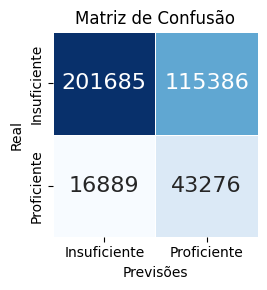

                                       Feature  Coefficient  Odds Ratio  \
2                               SEXO_Masculino     0.667380    1.949124   
18                    QTD_COMPUTADOR_3 ou mais     0.475402    1.608661   
0                                        const     0.401673    1.494322   
17                       QTD_COMPUTADOR_1 ou 2     0.361175    1.435015   
13                 ESCOL_MAE_Superior completo     0.347979    1.416203   
3                           SEXO_Não respondeu     0.316614    1.372473   
23                       GARAGEM_Não respondeu     0.306904    1.359210   
27              IDADE_INTROD_ESC_Não respondeu     0.260520    1.297604   
28                    REPROVACAO_Não respondeu     0.205670    1.228347   
10                    ESCOL_MAE_Médio completo     0.203452    1.225626   
20                            QTD_CARRO_1 ou 2     0.200976    1.222596   
40                      POS_EF_Somente estudar     0.182746    1.200510   
24                       

In [4]:
# Ajustando a variável alvo
df_2021['PROFICIENCIA_DESCRICAO'] = (
    df_2021['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Insuficiente': 'Insuficiente',
        'Proficiente': 'Proficiente',
        'Avançado': 'Proficiente'
    })
)

# Variável dependente
y = df_2021['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = df_2021.drop(columns=['PROFICIENCIA_DESCRICAO'])

# Dummies
X = pd.get_dummies(X, drop_first=True)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Remove NA
X = X.dropna()

# Alinha y
y = y.loc[X.index]

# Conversão
X = X.astype(float)
y = y.astype(int)

# Intercepto
X = sm.add_constant(X)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Distribuição das classes
print("Distribuição das classes:")
print(y_train.value_counts())

# Cálculo dos pesos
n_total = len(y_train)

n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()

peso_0 = n_total / (2 * n0)
peso_1 = n_total / (2 * n1)

print(f"\nPeso classe 0: {peso_0:.4f}")
print(f"Peso classe 1: {peso_1:.4f}")

weights = y_train.map({
    0: peso_0,
    1: peso_1
})

# Modelo Logístico Ponderado
modelo = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Binomial(),
    freq_weights=weights
).fit()

#print(modelo.summary())

# Previsões no conjunto de teste
y_prob = modelo.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

# Coeficientes do modelo
coef = modelo.params

# Calculando as Odds Ratios
odds_ratios = np.exp(coef)

# Calculando os p-values
p_values = modelo.pvalues

# Criando o DataFrame para exibir os coeficientes, Odds Ratios e p-values
resultado = pd.DataFrame({
    'Feature': coef.index,
    'Coefficient': coef.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})


# Ordenando por Odds Ratio
resultado = resultado.sort_values(
    by='Odds Ratio',
    ascending=False
)
print(resultado)

#### 2023

Distribuição das classes:
PROFICIENCIA_DESCRICAO
0    1365796
1     276328
Name: count, dtype: int64

Peso classe 0: 0.6012
Peso classe 1: 2.9713

Acurácia: 0.6439

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.91      0.63      0.75    341450
 Proficiente       0.28      0.70      0.40     69082

    accuracy                           0.64    410532
   macro avg       0.60      0.67      0.57    410532
weighted avg       0.81      0.64      0.69    410532



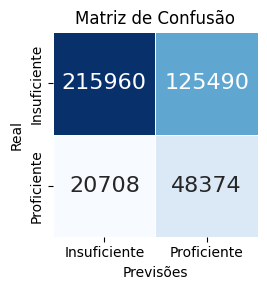

                                       Feature  Coefficient  Odds Ratio  \
4                           SEXO_Não respondeu     0.699688    2.013125   
2                               SEXO_Masculino     0.645514    1.906966   
19                    QTD_COMPUTADOR_3 ou mais     0.477887    1.612664   
14                 ESCOL_MAE_Superior completo     0.343480    1.409846   
18                       QTD_COMPUTADOR_1 ou 2     0.325953    1.385350   
3                       SEXO_Não quis declarar     0.305850    1.357779   
0                                        const     0.268484    1.307980   
24                       GARAGEM_Não respondeu     0.234349    1.264085   
41                      POS_EF_Somente estudar     0.226209    1.253838   
11                    ESCOL_MAE_Médio completo     0.221970    1.248534   
21                            QTD_CARRO_1 ou 2     0.177580    1.194323   
28              IDADE_INTROD_ESC_Não respondeu     0.165450    1.179924   
25                       

In [5]:
# Ajustando a variável alvo
df_2023['PROFICIENCIA_DESCRICAO'] = (
    df_2023['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Insuficiente': 'Insuficiente',
        'Proficiente': 'Proficiente',
        'Avançado': 'Proficiente'
    })
)

# Variável dependente
y = df_2023['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = df_2023.drop(columns=['PROFICIENCIA_DESCRICAO'])

# Dummies
X = pd.get_dummies(X, drop_first=True)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Remove NA
X = X.dropna()

# Alinha y
y = y.loc[X.index]

# Conversão
X = X.astype(float)
y = y.astype(int)

# Intercepto
X = sm.add_constant(X)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Distribuição das classes
print("Distribuição das classes:")
print(y_train.value_counts())

# Cálculo dos pesos
n_total = len(y_train)

n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()

peso_0 = n_total / (2 * n0)
peso_1 = n_total / (2 * n1)

print(f"\nPeso classe 0: {peso_0:.4f}")
print(f"Peso classe 1: {peso_1:.4f}")

weights = y_train.map({
    0: peso_0,
    1: peso_1
})

# Modelo Logístico Ponderado
modelo = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Binomial(),
    freq_weights=weights
).fit()

#print(modelo.summary())

# Previsões no conjunto de teste
y_prob = modelo.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

# Coeficientes do modelo
coef = modelo.params

# Calculando as Odds Ratios
odds_ratios = np.exp(coef)

# Calculando os p-values
p_values = modelo.pvalues

# Criando o DataFrame para exibir os coeficientes, Odds Ratios e p-values
resultado = pd.DataFrame({
    'Feature': coef.index,
    'Coefficient': coef.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})


# Ordenando por Odds Ratio
resultado = resultado.sort_values(
    by='Odds Ratio',
    ascending=False
)
print(resultado)